# Assignment 2: Airbnb - Exploring Pandas

Airbnb, Inc. is an online marketplace for arranging or offering lodging, primarily homestays, or tourism experiences. The company does not own any of the real estate listings, nor does it host events; it acts as a broker, receiving commissions from each booking (Wikipedia 2023).

For these exercises, we use original data from Airbnb for Boston that have been collected in December 2017 by the Airbnb API. The data shows some properties of Boston's real estate listings:

- Host information: year of registration, location, about, response time, response rate, acceptance rate, „is superhost“, total listings (number of accommodations), verifications, „has profile pic“, „identity verified“
- Location: Latitude, Longitude
- Property: property type, room type, accommodates, bathrooms, bedrooms, beds, price, security deposit, cleaning fee, guests included, extra people, min. nights, max. nights ,...
- Reviews: number of reviews, various reviews score, reviews per month

Let's exercise pandas and explore the airbnb data?


## 1) Import Pandas

In [3]:
import pandas as pd

## 2) Read in the Airbnb Data with Pandas

Use the .read_ecxel() function of pandas to import the airbnb data.

In [4]:
airbnb = pd.read_excel('https://github.com/casbdai/notebooks/raw/main/Module2/Onboarding/PrepTask/airbnb.xlsx')

## 3) Explore Size of Data Set

Use the .head() and .info() methods on the airbnb-DataFrame.

How many Instances and Features has the airbnb data set?
What data types are present in the data set? What is a data type of type object?


In [5]:
# using head()
airbnb.head()

,host_since,host_response_rate,host_is_superhost,host_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,room_type,accommodates,...,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,require_guest_profile_picture,calculated_host_listings_count,reviews_per_month
0,2016,100,0,1,1,1,42.274980,-71.139690,Private room,2,...,8,10,10,8,8,8,1,0,1,179
1,2016,100,1,1,1,0,42.276364,-71.136433,Private room,2,...,10,10,10,10,9,10,0,0,1,436
2,2017,100,0,2,1,0,42.290783,-71.137955,Private room,2,...,10,8,10,10,9,10,1,0,2,73
3,2016,100,0,4,1,0,42.276677,-71.135082,Private room,2,...,10,10,10,10,9,9,0,0,4,65
4,2015,0,0,1,1,1,42.287598,-71.134482,Private room,4,...,10,10,10,10,10,10,0,0,1,66


In [6]:
# using info()
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2351 entries, 0 to 2350
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_since                      2351 non-null   int64  
 1   host_response_rate              2351 non-null   int64  
 2   host_is_superhost               2351 non-null   int64  
 3   host_listings_count             2351 non-null   int64  
 4   host_has_profile_pic            2351 non-null   int64  
 5   host_identity_verified          2351 non-null   int64  
 6   latitude                        2351 non-null   float64
 7   longitude                       2351 non-null   float64
 8   room_type                       2351 non-null   object 
 9   accommodates                    2351 non-null   int64  
 10  bathrooms                       2351 non-null   int64  
 11  bedrooms                        2351 non-null   int64  
 12  beds                            23

Number of features: 34

Number of instances: 2351

The dataframe consists of following data types: floats (float64), integers (int64), object (as a string, "room type")

The data object/s is/are: String, as a category/text


## 4) Selecting the Feature "price"

Select the variable "price" and select it in the screen

In [9]:
# select the variable "price" from the airbnb dataframe
airbnb["price"]

,price
0,60
1,45
2,65
3,69
4,50
...,...
2346,159
2347,75
2348,110
2349,150


In [14]:
# select the variables "price" and "room_type" (use a list...) and the first 3 rows from the airbnb dataframe
airbnb[["price", "room_type",]][0:3]

,price,room_type
0,60,Private room
1,45,Private room
2,65,Private room


In [20]:
# select the first three features as well as rows 31 to 33 from the airbnb dataframe
airbnb.iloc[31:34, 0:3]

,host_since,host_response_rate,host_is_superhost
31,2013,0,0
32,2015,100,0
33,2015,100,0


## 5) Creating and deleting new variables

Create a new variable revenues per year.

In [25]:
# create a feature "number_of_years" by subtracting "first_review" from "last_review"
airbnb["number_of_years"] = airbnb["last_review"] - airbnb["first_review"]

# inspect results
airbnb["number_of_years"]

,number_of_years
0,0
1,1
2,0
3,0
4,0
...,...
2346,0
2347,0
2348,0
2349,0


Inspect the results: Why are there so many zeros in the output? What do they mean?

Answer: It seems like most the first and last reviews were recorded in the same year, therefore the difference is 0 in most cases. Since year is stored as an integer and not a precise date, it is more likely to have a difference of 0

In [26]:
# add 1 to your newly created variable "number_of_years" in order to fix that
airbnb["number_of_years_1"] = airbnb["number_of_years"] + 1

# inspect results
airbnb["number_of_years_1"]

,number_of_years_1
0,1
1,2
2,1
3,1
4,1
...,...
2346,1
2347,1
2348,1
2349,1


In [27]:
# create a variable "reviews_per_year"
airbnb["reviews_per_year"] = airbnb["number_of_reviews"]/airbnb["number_of_years_1"]

# inspect results
airbnb["reviews_per_year"]

,reviews_per_year
0,2.0
1,14.5
2,5.0
3,5.0
4,10.0
...,...
2346,1.0
2347,19.0
2348,3.0
2349,1.0


## 5) Summary Statistics

Pandas provides a series of useful functions for performing exploratory data analysis. Apply the method .mean() on the airbnb dataframe

What is the output?

In [30]:
# apply .mean() on airbnb()
airbnb.mean(numeric_only=True)

,0
host_since,2014.505317
host_response_rate,83.350915
host_is_superhost,0.204594
host_listings_count,41.013186
host_has_profile_pic,0.998724
host_identity_verified,0.584007
latitude,42.340226
longitude,-71.084592
accommodates,3.190132
bathrooms,7.794981


The output describes: The mean (average) value of each column, however numeric values only can be considered otherwise an error occurs due to the room_type object - no mean for strings

Now, calculate the mean, median, and the standard deviation of the feature "price".

Hint: Select the variable price and apply the mean method on that variable selection.

What is the difference of the three measures?

In [32]:
# calculate the mean price
airbnb["price"].mean()

np.float64(161.27052318162484)

In [34]:
# calculate the median price
airbnb["price"].median()

139.0

In [35]:
# calculate the standard deviation for price
airbnb["price"].std()

142.6317710232033

The difference between the three measures is:


*   Mean is an average of all the results, so in this case it is higher because there are some expensive rows driving the mean upwards, so rows are weighted by their values
*   Median is the middle number, so rows are weighted equally, not by their values and therefore less affected by outliers. So the 1175th row price is taken
*   Standard Deviation measures the spread of the values, so how thin or fat the bell curve is. The higher the value, the more spread out values are




## 6) Plotting


Create a scatterplot for the variables "price" and "number_of_reviews" . How would you interpret the results?

<Axes: xlabel='price', ylabel='number_of_reviews'>

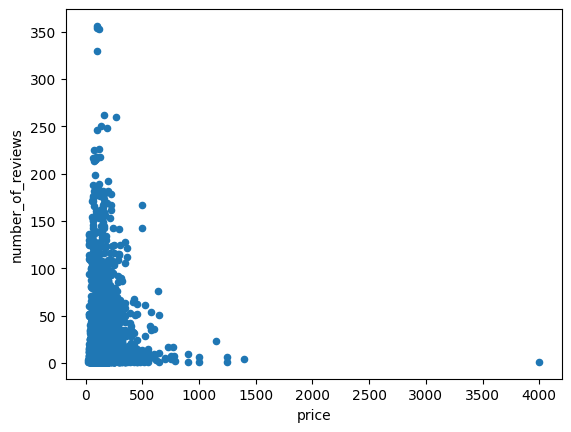

In [36]:
# create scatterplot
airbnb.plot(kind="scatter", x="price", y="number_of_reviews")

Your interpretation: the scatter plot suggests a negative correlation between price and number of reviews, however most data points are clustered so it is difficult to determine. There are some outliers, high price and high number of reviews which follow this negative correlation though.

Create a scatterplot for the variables longitude and latitude. How would you describe the results now? Hint: The data is from Boston....

<Axes: xlabel='longitude', ylabel='latitude'>

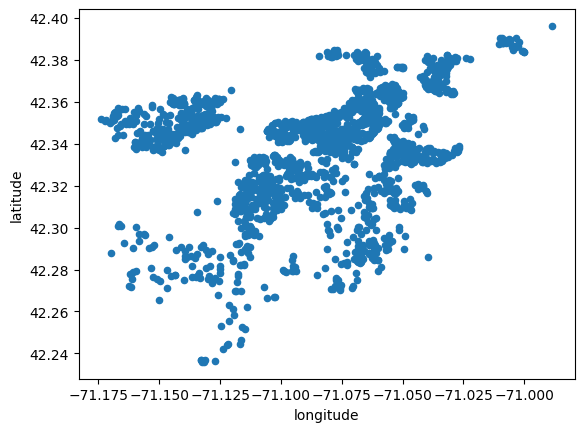

In [37]:
# create scatterplot
airbnb.plot(kind="scatter", x="longitude", y="latitude")

The data points represent clusters of airbnb locations on a geographical area. Since this is in Boston, it seems like there are several clusters of locations, probably representing different neighbourhoods and travel hubs

## 7) Subsetting Data


Select all instances which have more than 0 reviews

In [40]:
airbnb.loc[airbnb["number_of_reviews"] > 0]

,host_since,host_response_rate,host_is_superhost,host_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,room_type,accommodates,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,require_guest_profile_picture,calculated_host_listings_count,reviews_per_month,number_of_years,number_of_years_1,reviews_per_year
0,2016,100,0,1,1,1,42.274980,-71.139690,Private room,2,...,8,8,8,1,0,1,179,0,1,2.0
1,2016,100,1,1,1,0,42.276364,-71.136433,Private room,2,...,10,9,10,0,0,1,436,1,2,14.5
2,2017,100,0,2,1,0,42.290783,-71.137955,Private room,2,...,10,9,10,1,0,2,73,0,1,5.0
3,2016,100,0,4,1,0,42.276677,-71.135082,Private room,2,...,10,9,9,0,0,4,65,0,1,5.0
4,2015,0,0,1,1,1,42.287598,-71.134482,Private room,4,...,10,10,10,0,0,1,66,0,1,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2346,2014,99,0,79,1,0,42.331059,-71.118882,Entire home/apt,6,...,10,10,10,1,0,50,167,0,1,1.0
2347,2013,100,0,1,1,1,42.336990,-71.139537,Private room,2,...,10,10,10,1,0,1,255,0,1,19.0
2348,2017,100,0,1,1,0,42.396191,-70.988496,Entire home/apt,3,...,9,9,9,0,0,1,181,0,1,3.0
2349,2017,0,0,1,1,0,42.346980,-71.116780,Private room,2,...,10,10,6,1,0,1,167,0,1,1.0


Select all instances which are of "room_type" "Shared room" or "Private room".

Save the results to a new dataframe "airbnb_small" and use the info() method on this new dataframe. What has changed in comparison to the original airbnb dataframe

In [42]:
# Select room types "Shared room" and "Private Room" and assign results to a new dataframe
airbnb_small = airbnb[(airbnb["room_type"] == "Shared room") | (airbnb["room_type"] == "Private room")]

#apply .info() method on new dataframe
airbnb_small.info()

<class 'pandas.core.frame.DataFrame'>
Index: 929 entries, 0 to 2350
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_since                      929 non-null    int64  
 1   host_response_rate              929 non-null    int64  
 2   host_is_superhost               929 non-null    int64  
 3   host_listings_count             929 non-null    int64  
 4   host_has_profile_pic            929 non-null    int64  
 5   host_identity_verified          929 non-null    int64  
 6   latitude                        929 non-null    float64
 7   longitude                       929 non-null    float64
 8   room_type                       929 non-null    object 
 9   accommodates                    929 non-null    int64  
 10  bathrooms                       929 non-null    int64  
 11  bedrooms                        929 non-null    int64  
 12  beds                            929 non-

The number of rows decreased, because we filtered by room type so only 2 types of rooms are present now, therefore only 929 entries